# Plot Pole Figures

* Contributor: Javier Velo
* DAMASK version: 3.1.0

In [1]:
%matplotlib inline

In [2]:
import damask
import numpy as np
from scipy.ndimage import gaussian_filter
from matplotlib import pyplot  as plt
from matplotlib import colors  as clrs
from matplotlib import patches as patches

## Define orientations based on a fiber component

In [3]:
N_O = 1000      # number of orientations
ori = damask.Orientation.from_fiber_component(
    crystal = [np.pi/4.0, np.pi/3.0],
    sample = [np.pi/3.0, np.pi/6.0],
    shape = N_O,
    lattice = 'cF',
)

## Choose a lattice direction [uvw] and calculate lab frame representation

In [4]:
uvw = np.array([3, 2, 0])       # Lattice direction [u, v, w]
symm = True                     # compute all symmetrically equivalent directions

# Lab frame representation
lab = ori.to_frame(uvw=uvw,with_symmetry=symm)
proj = damask.util.project_equal_area(lab,'z')

## Separate binned stereographic projection into upper and lower hemispheres

In [5]:
plots = ['both','upper','lower']
mask = np.stack((
    np.ones(lab.shape[:-1],dtype=bool),   # both hemispheres
    lab[...,2] > 0,                       # upper hemisphere
    lab[...,2] <= 0,                      # lower hemisphere
    ),
    axis=0,
)

N_bins = 500

hist  = np.zeros(shape = [len(mask), N_bins, N_bins])
for i,m in enumerate(mask):
    hist[i] = gaussian_filter(np.histogram2d(x = proj[m,0],
                                             y = proj[m,1],
                                             range = [[-1,1],[-1,1]],
                                             bins = N_bins,
                                            )[0].T,
                              sigma = 1.5,
                              mode = 'constant',
                              cval = 0.0)


## Plot Densities

Axis are $+X$ to the right, $+Y$ up.
Clip the square grid with a circle of radius 1; anything beyond a radius 1 from the center is zero (nothing should be projected there)

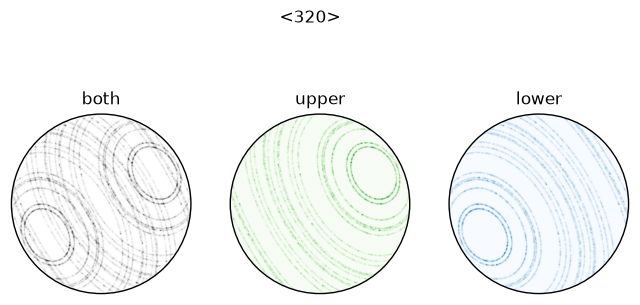

In [6]:
fig = plt.figure(figsize=(8,4))
fig.suptitle(f'{"<" if symm else "["}{"".join(map(str,uvw))}{">" if symm else "]"}')
for k,h in enumerate(hist):
    axs = fig.add_subplot(1,len(hist),k+1)
    axs.axis('off')                                # remove axis
    axs.set_title(plots[k])
    axs.set_xlim(-4,N_bins+4)                      # plot slightly beyond [-1,+1]
    axs.set_ylim(-4,N_bins+4)
    crc = patches.Circle(xy = [N_bins/2]*2, radius = N_bins/2, fill = False)
    img = plt.imshow(X = h,
                     cmap = ['Grays','Greens','Blues','Oranges','Reds'][k%5],
                     vmin = 0,
                     vmax = hist.max(),
                    )
    axs.add_patch(crc)
    img.set_clip_path(crc)                         # clip with circle

plt.show()